In [11]:
import numpy as np
import pandas as pd

from nbqol import path_to_git_root

dir = path_to_git_root() # automatically makes path to repo directory (wherever you cloned it)

print("Repository directory: ", dir)

# type(dir)

Repository directory:  /mnt/c/Users/Timothy/Documents/Chou


In [12]:
'''
Preprocessing crispr ev data
'''

crispr_df = pd.read_csv(dir + '/data/EV_vs_PBS_DESeq2_results (Screen DESEQ2).txt', sep='\t')
crispr_df = crispr_df.drop(['sgID'], axis=1)
crispr_df = crispr_df[crispr_df['padj'] < 0.05]
crispr_df['line'] = 'CRISPR-screen'
crispr_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,line
0,5091.560713,2.520888,0.167190,15.078008,2.259839e-51,4.766226e-47,MYBL2,CRISPR-screen
1,10477.715334,2.835960,0.191290,14.825456,1.002966e-49,1.057677e-45,MCM3,CRISPR-screen
2,2740.980366,2.498570,0.228676,10.926241,8.635191e-28,6.070827e-24,MED22,CRISPR-screen
3,2422.113243,2.930149,0.275746,10.626272,2.249243e-26,1.185970e-22,GINS4,CRISPR-screen
4,3037.835527,2.896625,0.283393,10.221233,1.593011e-24,6.719638e-21,MCM2,CRISPR-screen
...,...,...,...,...,...,...,...,...
822,2443.027190,-0.794453,0.256103,-3.102082,1.921646e-03,4.924597e-02,SFSWAP,CRISPR-screen
823,5494.775991,-0.578792,0.186646,-3.101009,1.928627e-03,4.936489e-02,GTF2I,CRISPR-screen
824,1467.461281,1.386205,0.447507,3.097616,1.950843e-03,4.987301e-02,NOL11,CRISPR-screen
825,2704.423870,0.818670,0.264338,3.097062,1.954487e-03,4.990567e-02,MAP2K6,CRISPR-screen


In [13]:
'''
Preprocessing rt112 data
'''

rt112 = pd.read_csv(dir + '/data/rp_vs_rr/rp_vs_rr_summary.txt', sep='\t')
rt112 = rt112[rt112['padj'] < 0.05]
rt112 = rt112.rename(columns={'GeneSymbol': 'gene'})
#rt112['padj'].describe()
rt112['line'] = 'RT112'
rt112

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,gene_type,line
0,1933.153304,-3.375006,0.083720,-40.312927,0.000000,0.000000,F3,protein_coding,RT112
1,7291.676853,5.953054,0.084600,70.367366,0.000000,0.000000,TXNIP,protein_coding,RT112
2,1894.517793,-4.164389,0.099914,-41.679786,0.000000,0.000000,DHRS9,protein_coding,RT112
3,1409.878109,-4.876914,0.118682,-41.092419,0.000000,0.000000,AREG,protein_coding,RT112
4,1662.933358,-3.886193,0.092667,-41.937209,0.000000,0.000000,SLC7A11,protein_coding,RT112
...,...,...,...,...,...,...,...,...,...
10527,3.500634,3.296596,1.437656,2.293035,0.021846,0.049898,ZNF541,protein_coding,RT112
10528,736.233648,0.253272,0.110463,2.292825,0.021858,0.049917,ALMS1,protein_coding,RT112
10529,2.691250,3.704446,1.615764,2.292691,0.021866,0.049930,RP11-762L8.1,processed_pseudogene,RT112
10530,318.387369,0.298058,0.130023,2.292343,0.021886,0.049966,PARP3,protein_coding,RT112


Sort by ALL upregulated and ALL downregulated genes --> then find overlap

In [14]:
'''
Sort by ALL upregulated and ALL downregulated genes --> then find overlap
- Requires log2FoldChange > 1 for upregulated and < -1 for downregulated
'''


rt112_top = rt112.sort_values('log2FoldChange', ascending = False) #top upregulated genes
rt112_top = rt112_top[rt112_top['log2FoldChange'] > 1]

rt112_bottom = rt112.sort_values('log2FoldChange', ascending = True) #top downregulated genes
rt112_bottom = rt112_bottom[rt112_bottom['log2FoldChange'] < -1]


crispr_top = crispr_df.sort_values('log2FoldChange', ascending = False) #top upregulated genes
crispr_top = crispr_top[crispr_top['log2FoldChange'] > 1]

crispr_bottom = crispr_df.sort_values('log2FoldChange', ascending = True) #top downregulated genes
crispr_bottom = crispr_bottom[crispr_bottom['log2FoldChange'] < -1]

print("Number of upregulated genes in RT112: ", len(rt112_top))
print("Number of downregulated genes in RT112: ", len(rt112_bottom))

print("Number of upregulated genes in CRISPR: ", len(crispr_top))
print("Number of downregulated genes in CRISPR: ", len(crispr_bottom))

Number of upregulated genes in RT112:  1944
Number of downregulated genes in RT112:  2022
Number of upregulated genes in CRISPR:  566
Number of downregulated genes in CRISPR:  50


In [15]:
overlap = set(rt112_top['gene'].tolist()) & set(crispr_top['gene'].tolist())
print('Overlapping upregulated genes: ', overlap)

overlap = set(rt112_bottom['gene'].tolist()) & set(crispr_bottom['gene'].tolist())
print('Overlapping downregulated genes: ', overlap)

Overlapping upregulated genes:  {'PRIM1', 'POLA2', 'LAGE3', 'POP5', 'RFC4', 'RFC3', 'CLSPN', 'SSX2IP', 'SNN', 'PWP2', 'MCM3', 'BRCA1', 'GINS2', 'SPC25', 'CDK1', 'MCM10', 'MAGOHB', 'KCNAB1', 'RAD51D', 'MYBL2'}
Overlapping downregulated genes:  {'ZNF185', 'ACCS', 'ZNF585B', 'TSC1', 'EPGN'}


Sort by t100 upregulated and t100 downregulated genes --> then find overlap

In [16]:
'''
Sort by t100 upregulated and t100 downregulated genes --> then find overlap
- Doesn't take into account log2FoldChange values
'''

rt112_top100 = rt112.sort_values('log2FoldChange', ascending = False).head(100) #top 100 upregulated genes
rt112_bottom100 = rt112.sort_values('log2FoldChange', ascending = True).head(100) #top 100 downregulated genes

crispr_top100 = crispr_df.sort_values('log2FoldChange', ascending = False).head(100) #top 100 upregulated genes
crispr_bottom100 = crispr_df.sort_values('log2FoldChange', ascending = True).head(100) #top 100 downregulated genes

overlap = set(rt112_top100['gene'].tolist()) & set(crispr_top100['gene'].tolist())
print('Overlapping upregulated genes: ', overlap)

overlap = set(rt112_bottom100['gene'].tolist()) & set(crispr_bottom100['gene'].tolist())
print('Overlapping downregulated genes: ', overlap)

Overlapping upregulated genes:  set()
Overlapping downregulated genes:  {'ACCS'}


In [17]:
'''
venn diagrams
'''

import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns

In [18]:
rt112_top['gene']

1121         PI3
1956        SAA1
1727       ABCB1
464        PRSS2
2986       SEMG1
          ...   
7297       PRRT3
3370       ACTA2
1983      SETMAR
882     RNASEH2B
2278     C12orf4
Name: gene, Length: 1944, dtype: object

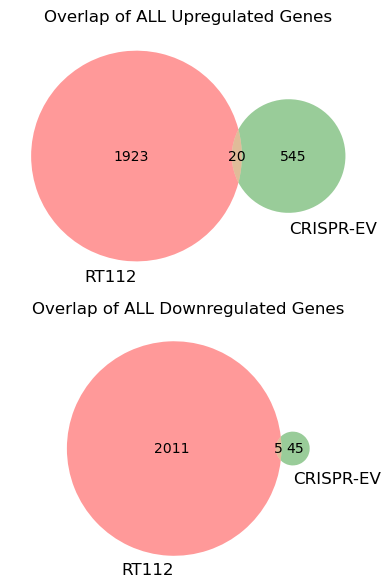

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6))

# Upregulated
plt.sca(axes[0])
venn2(
    [set(rt112_top['gene'].astype(str)), set(crispr_top['gene'].astype(str))],
    set_labels=('RT112', 'CRISPR-EV'),
    ax=axes[0]
)
axes[0].set_title('Overlap of ALL Upregulated Genes')

# Downregulated
plt.sca(axes[1])
venn2(
    [set(rt112_bottom['gene'].astype(str)), set(crispr_bottom['gene'].astype(str))],
    set_labels=('RT112', 'CRISPR-EV'),
    ax=axes[1]
)
axes[1].set_title('Overlap of ALL Downregulated Genes')

plt.tight_layout()
plt.show()

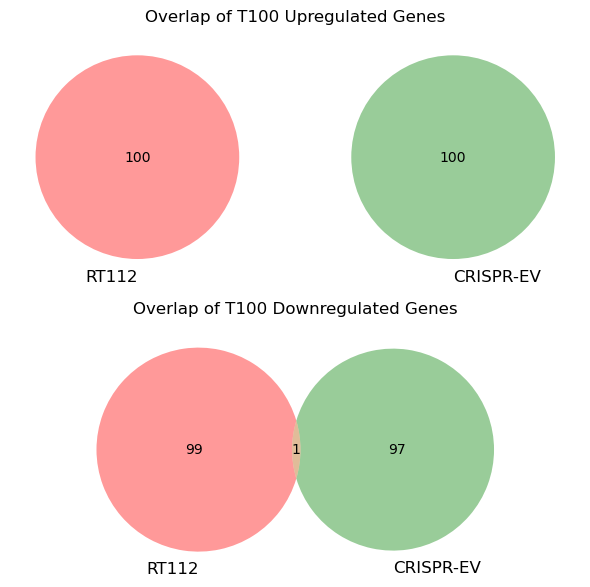

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6))

# Upregulated
plt.sca(axes[0])
venn2(
    [set(rt112_top100['gene'].astype(str)), set(crispr_top100['gene'].astype(str))],
    set_labels=('RT112', 'CRISPR-EV'),
    ax=axes[0]
)
axes[0].set_title('Overlap of T100 Upregulated Genes')

# Downregulated
plt.sca(axes[1])
venn2(
    [set(rt112_bottom100['gene'].astype(str)), set(crispr_bottom100['gene'].astype(str))],
    set_labels=('RT112', 'CRISPR-EV'),
    ax=axes[1]
)
axes[1].set_title('Overlap of T100 Downregulated Genes')

plt.tight_layout()
plt.show()

Low overlap b/w RT112 and CRISPR-EV line from tamilla. Could be that resistant cell line adapted via different genetic or epigenetic pathway than the ones in the CRISPR screen?

Since resistant cell line acquired resistance through expression changes rather than simple knockouts

- Should look into pathway-level overlap and maybe if genes correlate w/ each other across cell lines?